<a href="https://colab.research.google.com/github/shubhamunt/HPC_at_UTD/blob/main/Workshop_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Machine Learning and High Performance Computing

## Part II: Introduction to Machine Learning
### Tree-based Models

## 0. Setup

In [ ]:
# Check and install required packages
import importlib
import sys
import subprocess

# List of required packages
required_packages = [
    "numpy", "pandas", "matplotlib", "seaborn", "scikit-learn"
]

# Install missing ones
for pkg in required_packages:
    if importlib.util.find_spec(pkg) is None:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
    else:
        print(f"{pkg} already installed.")

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, BaggingClassifier, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

sns.set(style="whitegrid", font_scale=1.2, palette="deep")

numpy already installed.
pandas already installed.
matplotlib already installed.
seaborn already installed.
Installing scikit-learn...


## 1. Case 1: California Housing (Regression)

### 1.1 Dataset Overview
California Housing Dataset

**Dataset source:** `sklearn.datasets.fetch_california_housing` or the link: https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.tgz
- **Data size:** 20,640 observations (California districts)
- **Features:** 8 numeric predictors describing demographic and geographic characteristics  
  *(e.g., median income, average rooms, house age, population, latitude, longitude)*
- **Target:** median house value (continuous outcome, used for regression tasks)
- **Task type:** Regression — predict median house price from neighborhood features


In [ ]:
# Load California Housing Dataset (Regression)
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target

# Print basic dataset information
print("Data Overview:")
housing.frame.info()
print("-" * 80 + "\n")

# Check for missing values
missing_counts = housing.frame.isna().sum()
missing_counts = missing_counts[missing_counts > 0]
if not missing_counts.empty:
    print("Features with Missing Values:")
    print(missing_counts)
else:
    print("No missing values detected.")
print("-" * 80)

print("\n First 5 Rows of the Dataset:")
display(housing.frame.head())



Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
--------------------------------------------------------------------------------

No missing values detected.
--------------------------------------------------------------------------------

 First 5 Rows of the Dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 1.2 Regression Tree



### 1) Fit a basic regression tree and visualize the structure

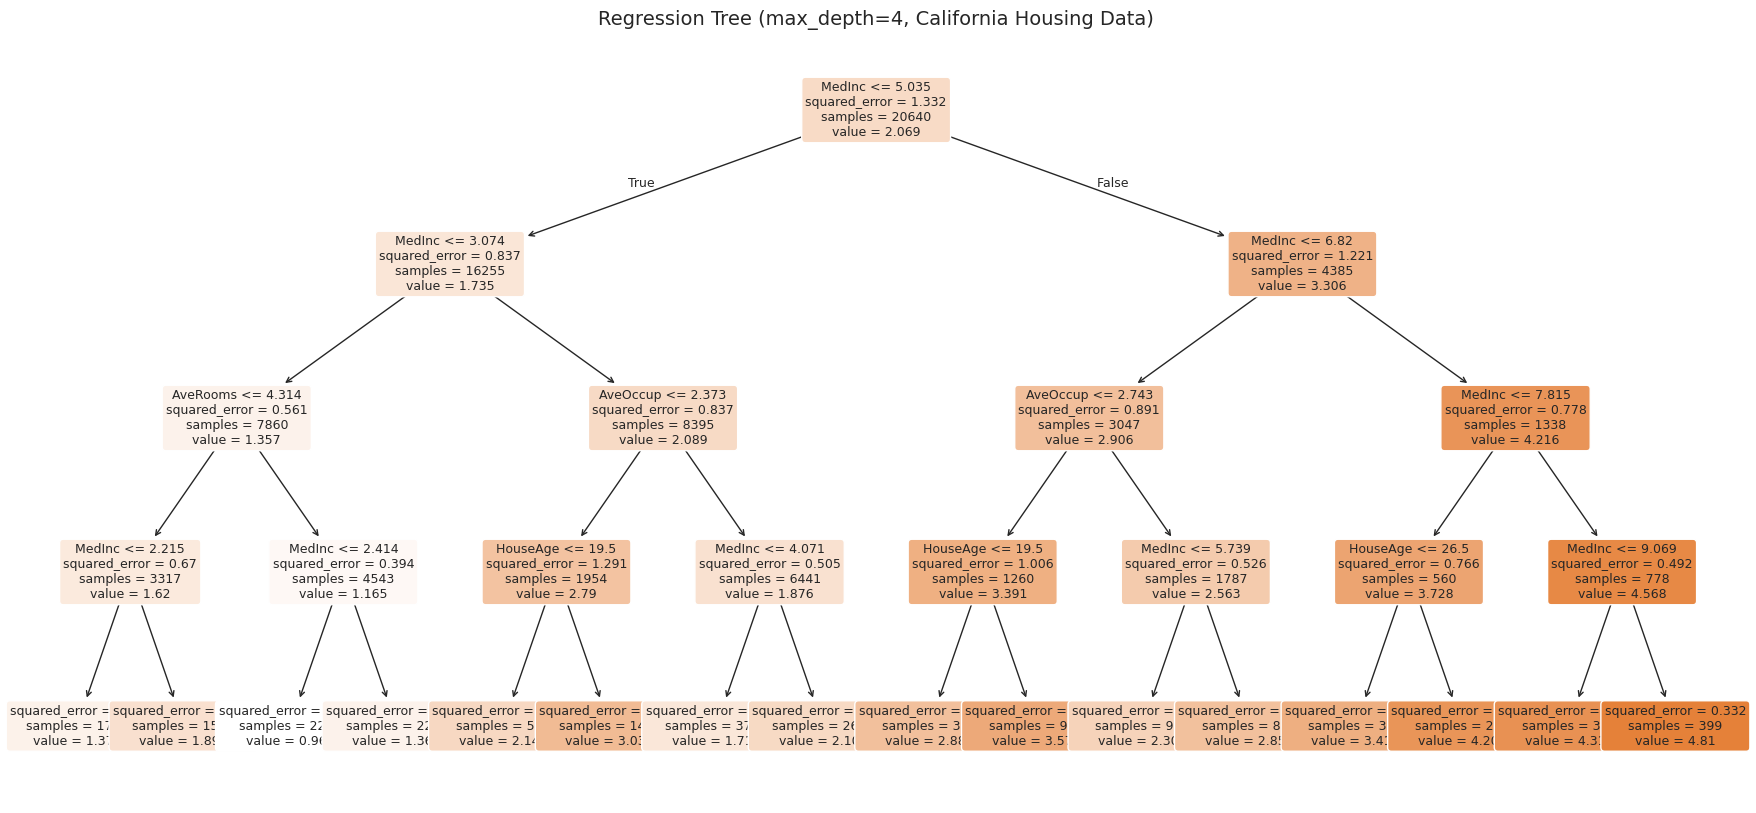

In [ ]:
# Fit a simple tree for interpretability
tree_reg = DecisionTreeRegressor(max_depth=4, random_state=2025)
tree_reg.fit(X, y)

# Plot the regression tree
plt.figure(figsize=(22, 10))
plot_tree(
    tree_reg,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Regression Tree (max_depth=4, California Housing Data)", fontsize=14)
plt.show()

### 2) Train vs Test MSE by Tree Depth (Bias–Variance Trade-off)

* The training error decreases with model complexity.

* The validation error first decreases (bias ↓) and then increases (variance ↑).
→ The sweet spot = balance between bias and variance.

* Find the optimal tree depth that minimizes validation MSE.

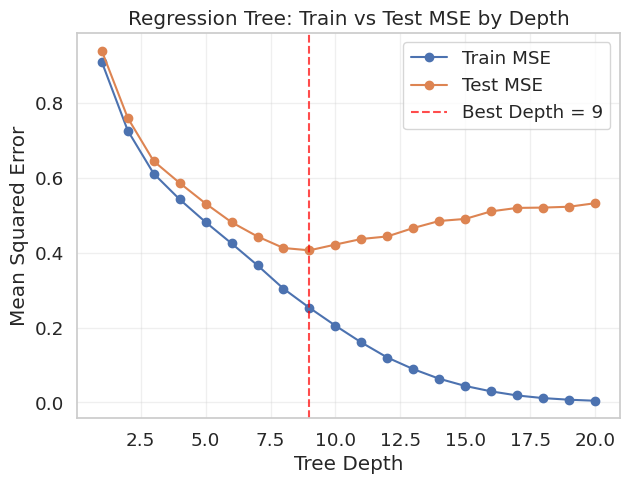

Best depth (by Test MSE): 9
Minimum Test MSE: 0.4065


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=2025
)

# Define the range of tree depths
depths = range(1, 21)

train_mse, test_mse = [], []

# Loop over tree depths
for d in depths:
    tree = DecisionTreeRegressor(max_depth=d, random_state=2025)
    tree.fit(X_train, y_train)

    y_pred_train = tree.predict(X_train)
    y_pred_test = tree.predict(X_test)

    train_mse.append(mean_squared_error(y_train, y_pred_train))
    test_mse.append(mean_squared_error(y_test, y_pred_test))

# --- Visualization ---
best_depth_test = depths[np.argmin(test_mse)]

plt.figure(figsize=(7, 5))
plt.plot(depths, train_mse, marker='o', label='Train MSE')
plt.plot(depths, test_mse, marker='o', label='Test MSE')
plt.axvline(best_depth_test, color='red', linestyle='--', alpha=0.7,
            label=f"Best Depth = {best_depth_test}")
plt.title("Regression Tree: Train vs Test MSE by Depth")
plt.xlabel("Tree Depth")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Best depth (by Test MSE): {best_depth_test}")
print(f"Minimum Test MSE: {min(test_mse):.4f}")


### 3) K-Fold Cross-Validation for Depth Selection (more stable)

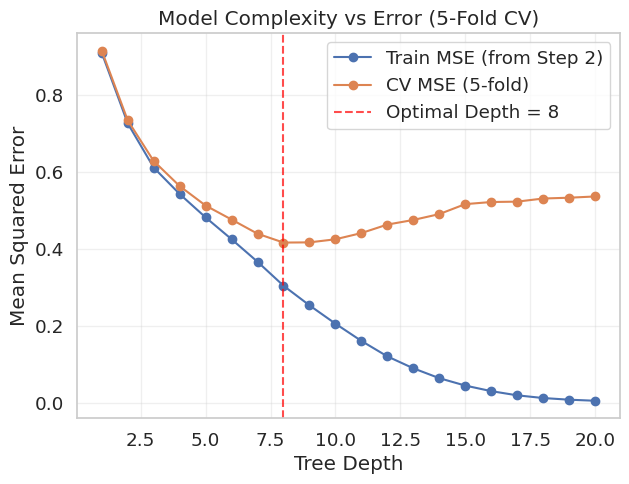

Optimal depth (by 5-fold CV): 8
Minimum CV MSE: 0.4163


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=2025)
cv_mse = []

for d in depths:
    tree = DecisionTreeRegressor(max_depth=d, random_state=2025)
    scores = cross_val_score(tree, X_train, y_train,
                             cv=kf, scoring='neg_mean_squared_error')
    cv_mse.append(-np.mean(scores))

best_depth_cv = depths[np.argmin(cv_mse)]

plt.figure(figsize=(7, 5))
plt.plot(depths, train_mse, marker='o', label='Train MSE (from Step 2)')
plt.plot(depths, cv_mse, marker='o', label='CV MSE (5-fold)')
plt.axvline(best_depth_cv, color='red', linestyle='--', alpha=0.7,
            label=f"Optimal Depth = {best_depth_cv}")
plt.title("Model Complexity vs Error (5-Fold CV)")
plt.xlabel("Tree Depth")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Optimal depth (by 5-fold CV): {best_depth_cv}")
print(f"Minimum CV MSE: {min(cv_mse):.4f}")

### 4) Variable Importance in Regression Tree

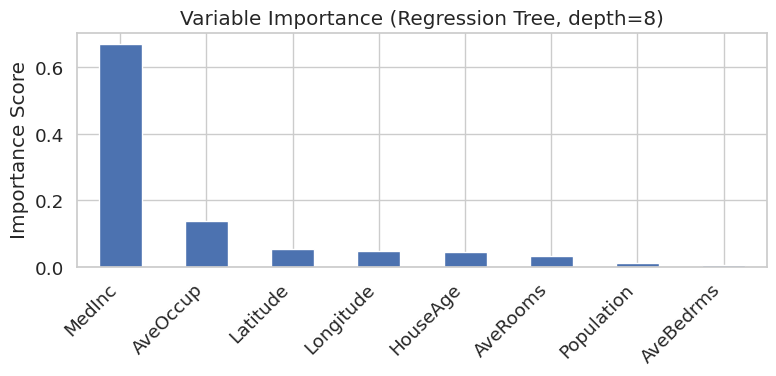

In [ ]:
# Set max_depth = optimal depth
tree_reg = DecisionTreeRegressor(max_depth=best_depth_cv, random_state=2025)

# Fit model on full data for variable importance
tree_reg.fit(X, y)

# Compute and display feature importance
importance = pd.Series(tree_reg.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

# Plot top features
plt.figure(figsize=(8,4))
importance[:10].plot(kind='bar')
plt.title(f'Variable Importance (Regression Tree, depth={best_depth_cv})')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 1.3 Bagging Tree & Random Forest (Regression)


### 1) K-fold CV and MSE

In [ ]:
# Bagging Tree
bag_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=50,
    random_state=2025
    )

# Random Forest Tree (default max_features=p/3)
rf_reg   = RandomForestRegressor(
    n_estimators=50,
    random_state=2025
    )

# K-fold CV (K=5)
kf = KFold(n_splits=5, shuffle=True, random_state=2025)

# Comparison of MSE
models = {
    "Decision Tree": tree_reg,
    "Bagging": bag_reg,
    "Random Forest": rf_reg
}

print("5-Fold Cross-Validation MSE:")
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
    mse_scores = -scores
    print(f"{name:15s}  MSE = {mse_scores.mean():.4f} ± {mse_scores.std():.4f}")

5-Fold Cross-Validation MSE:
Decision Tree    MSE = 0.4162 ± 0.0270
Bagging          MSE = 0.2564 ± 0.0163
Random Forest    MSE = 0.2565 ± 0.0167


### 2) True vs Predicted

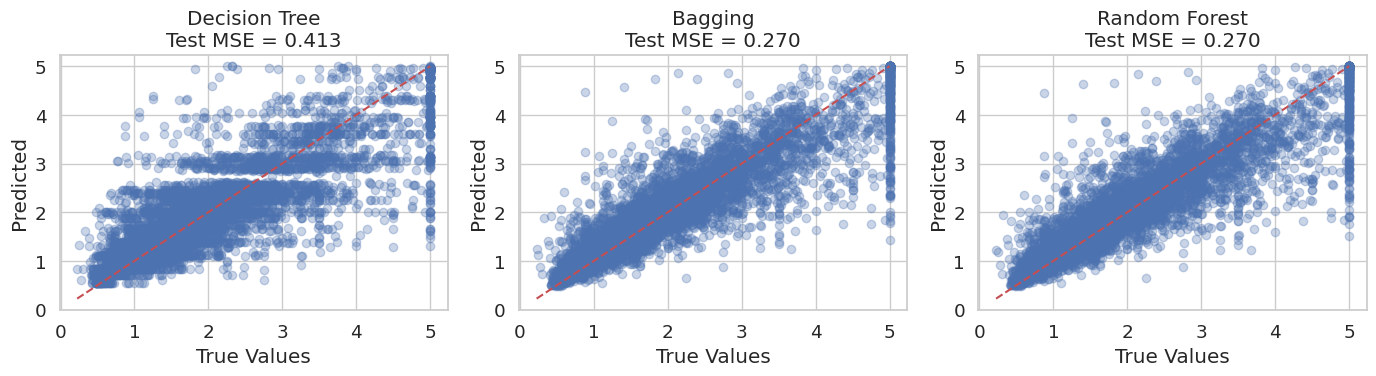

In [ ]:
plt.figure(figsize=(14,4))
for i, (name, model) in enumerate(models.items(), 1):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse_test = mean_squared_error(y_test, y_pred)

    plt.subplot(1,3,i)
    plt.scatter(y_test, y_pred, alpha=0.3)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title(f"{name}\nTest MSE = {mse_test:.3f}")
    plt.xlabel("True Values")
    plt.ylabel("Predicted")

plt.tight_layout()
plt.show()

### 3) Variable Importance Comparison


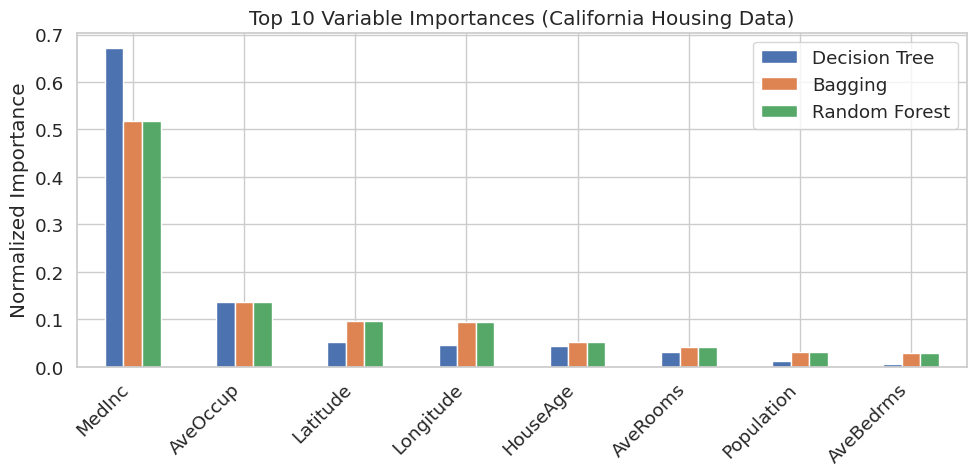

In [ ]:
# Fit models on full data (for importance comparison)
tree_reg.fit(X, y)
bag_reg.fit(X, y)
rf_reg.fit(X, y)

# Compute variable importance
imp_tree = pd.Series(tree_reg.feature_importances_, index=X.columns)
imp_rf   = pd.Series(rf_reg.feature_importances_, index=X.columns)

# For Bagging: average over all base estimators
bag_imp_list = []
for est in bag_reg.estimators_:
    bag_imp_list.append(est.feature_importances_)
imp_bagging = pd.Series(np.mean(bag_imp_list, axis=0), index=X.columns)

# Combine into one DataFrame
importance_df = pd.DataFrame({
    "Decision Tree": imp_tree,
    "Bagging": imp_bagging,
    "Random Forest": imp_rf
})

# Normalize for better visual comparison
importance_df = importance_df / importance_df.sum()

# Select top 10 features based on Random Forest importance
top_features = importance_df["Random Forest"].sort_values(ascending=False).head(10).index

# Plot
importance_df.loc[top_features].plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Variable Importances (California Housing Data)")
plt.ylabel("Normalized Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Case 2: Breast Cancer (Classification)
### 2.1 Dataset Overview
Breast Cancer Dataset

**Dataset source:** `sklearn.datasets.load_breast_cancer`  
- **Data size:** 569 observations (patients)  
- **Features:** 30 numeric predictors describing tumor cell characteristics  
  *(e.g., mean radius, texture, perimeter, area, smoothness, compactness)*  
- **Target:** binary label — `0 = malignant`, `1 = benign`  
- **Task type:** Classification — predict whether a tumor is malignant or benign based on its cell features


In [ ]:
# Load Breast Cancer dataset (Classification)
breast = load_breast_cancer(as_frame=True)
X, y = breast.data, breast.target

print("Data Dimensions / Shape:")
print(f"X shape: {X.shape[0]} samples × {X.shape[1]} features")
print(f"y shape: {y.shape[0]} labels")
print("-" * 80 + "\n")

# Check for missing values
missing_counts = breast.frame.isna().sum()
missing_counts = missing_counts[missing_counts > 0]
if not missing_counts.empty:
    print("Features with Missing Values:")
    print(missing_counts)
else:
    print("No missing values detected.")
print("-" * 80)

# Show first 5 rows
print("\nFirst 5 Rows of the Dataset:")
display(breast.frame.head())
print("-" * 80)

# Target distribution
print("\nTarget Distribution:")
print(y.value_counts().rename(index={0: "malignant", 1: "benign"}))


Data Dimensions / Shape:
X shape: 569 samples × 30 features
y shape: 569 labels
--------------------------------------------------------------------------------

No missing values detected.
--------------------------------------------------------------------------------

First 5 Rows of the Dataset:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


--------------------------------------------------------------------------------

Target Distribution:
target
benign       357
malignant    212
Name: count, dtype: int64


## 2.2 Classification Tree


### 1) Fit a simple classification tree and visualize

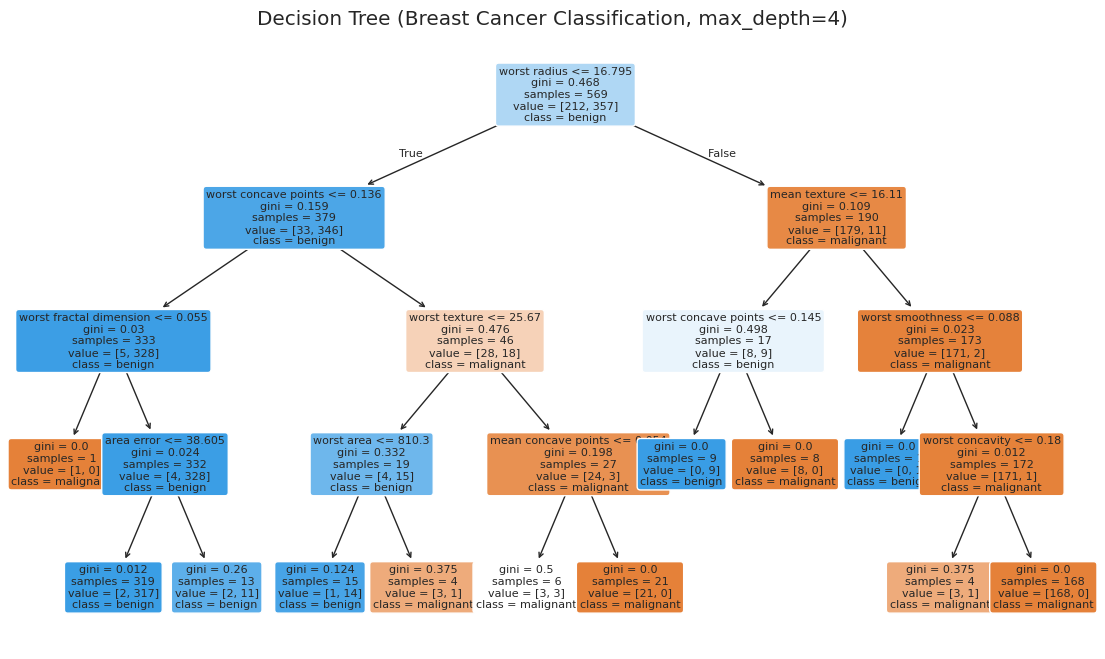

In [ ]:
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=2025)
tree_clf.fit(X, y)

plt.figure(figsize=(14, 8))
plot_tree(
    tree_clf,
    feature_names=X.columns,
    class_names=breast.target_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree (Breast Cancer Classification, max_depth=4)")
plt.show()

### 2） Train vs Test Accuracy by Depth (Bias–Variance Trade-off)

* The training accuracy increases with model complexity.  
* The test accuracy first increases (bias ↓) and then decreases (variance ↑).  
→ The sweet spot = the depth that balances bias and variance (best generalization).


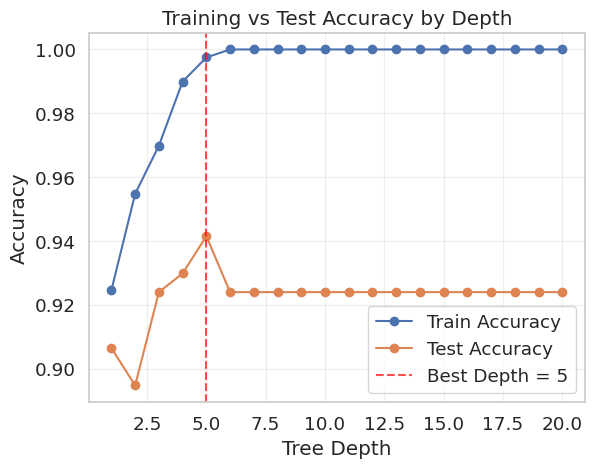

Best depth (by Test Accuracy): 5
Maximum Test Accuracy: 0.9415


In [ ]:
# Training Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=2025
)

# Define range of tree depths to evaluate
depths = range(1, 21)

# Initialize lists to store
train_acc, test_acc = [], []

for d in depths:
    # Train a classification tree with given depth
    tree = DecisionTreeClassifier(max_depth=d, random_state=2025)
    tree.fit(X_train, y_train)
    train_acc.append(tree.score(X_train, y_train))
    test_acc.append(tree.score(X_test, y_test))

# Find the depth that gives the highest cross-validation accuracy
best_depth_test = depths[np.argmax(test_acc)]

# Visualization
plt.plot(depths, train_acc, marker='o', label='Train Accuracy')
plt.plot(depths, test_acc, marker='o', label='Test Accuracy')

plt.axvline(best_depth_test, color='red', linestyle='--', alpha=0.7,
            label=f"Best Depth = {best_depth_test}")
plt.title("Training vs Test Accuracy by Depth")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Best depth (by Test Accuracy): {best_depth_test}")
print(f"Maximum Test Accuracy: {max(test_acc):.4f}")


### 3) K-Fold Cross-Validation for Depth Selection (5-fold CV)

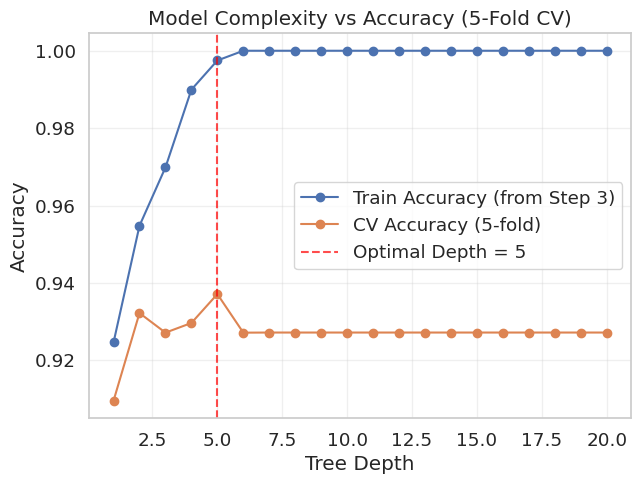

Optimal depth (by 5-fold CV): 5
Cross-validated Accuracy: 0.9371


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=2025)
cv_acc = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=2025)
    scores = cross_val_score(tree, X_train, y_train, cv=kf, scoring='accuracy')
    cv_acc.append(np.mean(scores))

best_depth_cv = depths[np.argmax(cv_acc)]
best_cv_acc = max(cv_acc)

plt.figure(figsize=(7, 5))
plt.plot(depths, train_acc, marker='o', label='Train Accuracy (from Step 3)')
plt.plot(depths, cv_acc, marker='o', label='CV Accuracy (5-fold)')
plt.axvline(best_depth_cv, color='red', linestyle='--', alpha=0.7,
            label=f"Optimal Depth = {best_depth_cv}")
plt.title("Model Complexity vs Accuracy (5-Fold CV)")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Optimal depth (by 5-fold CV): {best_depth_cv}")
print(f"Cross-validated Accuracy: {best_cv_acc:.4f}")

## 2.3 Ensemble Methods: Bagging & Random Forest
### 1) K-fold CV and Accuracy

In [ ]:
# Set max_depth of Classification Tree as optimal depth
tree_clf = DecisionTreeClassifier(max_depth=best_depth_cv, random_state=2025)

# Bagging Tree
bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=2025
)

# Random Forest (default max_features="sqrt")
rf_clf = RandomForestClassifier(
    n_estimators=50,
    random_state=2025
)

# K-fold CV （k=5)
kf = KFold(n_splits=5, shuffle=True, random_state=2025)

# Evaluate with cross_val_score (accuracy)
models = {
    "Decision Tree": tree_clf,
    "Bagging": bag_clf,
    "Random Forest": rf_clf
}

print("5-Fold Cross-Validation Accuracy Comparison:")
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
    print(f"{name:15s}  Accuracy = {np.mean(scores):.3f} ± {np.std(scores):.3f}")

5-Fold Cross-Validation Accuracy Comparison:
Decision Tree    Accuracy = 0.942 ± 0.013
Bagging          Accuracy = 0.960 ± 0.012
Random Forest    Accuracy = 0.961 ± 0.022


### 2) Confusion Matrices Comparison

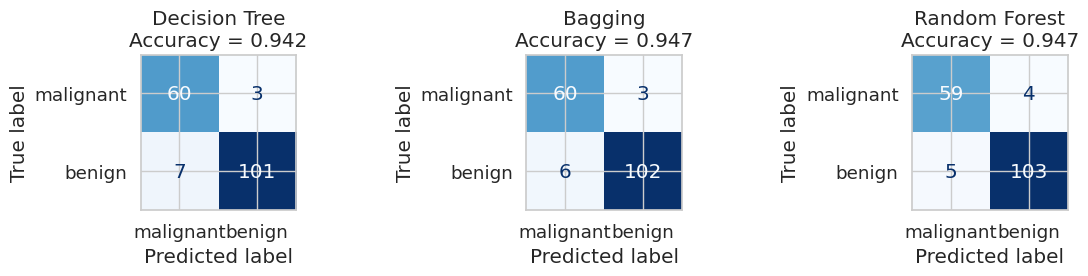

In [ ]:
# Fit the models
for model in models.values():
    model.fit(X_train, y_train)

# Confusion Matrices
plt.figure(figsize=(12, 3))
for i, (name, model) in enumerate(models.items(), 1):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.subplot(1, 3, i)
    disp = ConfusionMatrixDisplay(cm, display_labels=breast.target_names)
    disp.plot(ax=plt.gca(), cmap="Blues", colorbar=False)
    plt.title(f"{name}\nAccuracy = {model.score(X_test, y_test):.3f}")
plt.tight_layout()
plt.show()


### 3)  ROC Curves Comparison

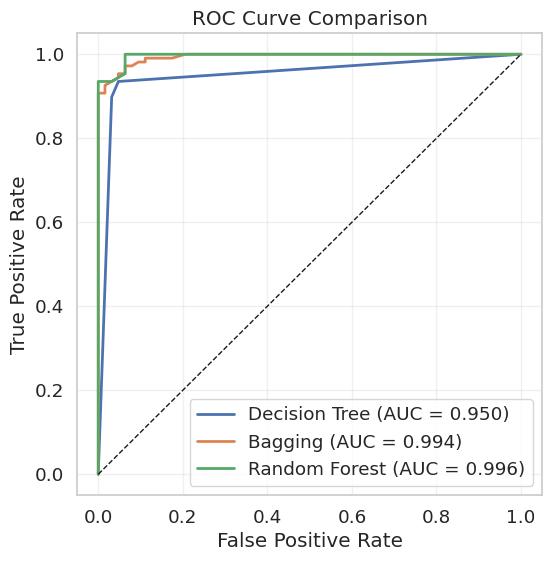

In [ ]:
# Compute ROC curve and AUC
plt.figure(figsize=(6, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### 4) Variable Importance Comparison

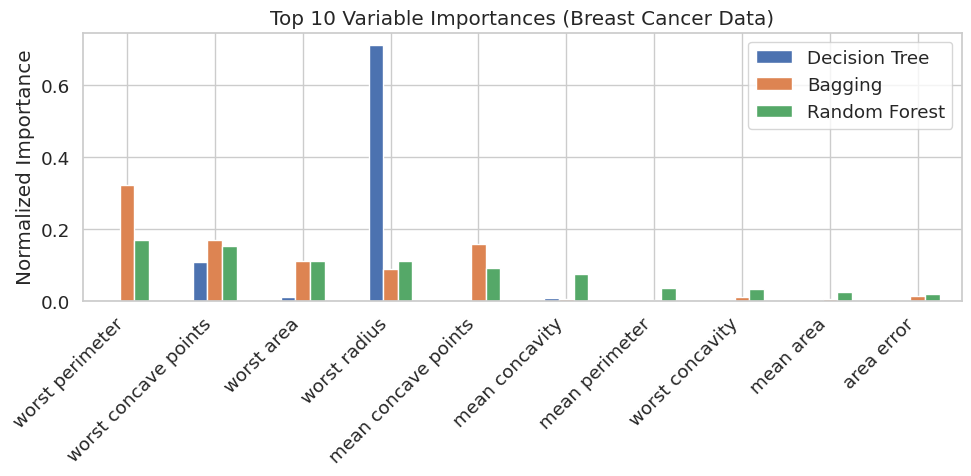

In [ ]:
# Fit on full data for feature importance
tree_clf.fit(X, y)
bag_clf.fit(X, y)
rf_clf.fit(X, y)

# Decision Tree & RF have .feature_importances_
imp_tree = pd.Series(tree_clf.feature_importances_, index=X.columns)
imp_rf   = pd.Series(rf_clf.feature_importances_, index=X.columns)

# Bagging: average feature_importances_ from each base estimator
bag_imp_list = []
for est in bag_clf.estimators_:
    bag_imp_list.append(est.feature_importances_)
imp_bag = pd.Series(np.mean(bag_imp_list, axis=0), index=X.columns)

# Combine and normalize
importance_df = pd.DataFrame({
    "Decision Tree": imp_tree,
    "Bagging": imp_bag,
    "Random Forest": imp_rf
})
importance_df = importance_df / importance_df.sum()

# Top 10 features based on Random Forest
top_features = importance_df["Random Forest"].sort_values(ascending=False).head(10).index

# Plot
importance_df.loc[top_features].plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Variable Importances (Breast Cancer Data)")
plt.ylabel("Normalized Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
# Supplementary: R Version

### 0) Setup

In [ ]:
# Install rpy2 interface to enable %%R magic
!pip install -q rpy2
# Loads the R extension
%load_ext rpy2.ipython

In [ ]:
%%R

# Automatically install missing packages
required_packages <- c("MASS", "rpart", "rpart.plot", "caret", "ggplot2",
                       "randomForest", "ipred", "pROC", "Metrics")

# Check which packages are not installed
missing_packages <- required_packages[!(required_packages %in% installed.packages()[,"Package"])]

# Install missing ones
if(length(missing_packages)) {
  install.packages(missing_packages, dependencies = TRUE)
}

# Load required packages
library(MASS)
library(rpart)
library(rpart.plot)
library(caret)
library(ggplot2)
library(randomForest)
library(ipred)
library(pROC)
library(Metrics)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘rbibutils’, ‘R.methodsS3’, ‘R.oo’, ‘R.utils’, ‘bitops’, ‘listenv’, ‘parallelly’, ‘Rdpack’, ‘R.cache’, ‘caTools’, ‘future’, ‘globals’, ‘plotrix’, ‘profileModel’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘lazyeval’, ‘styler’, ‘classInt’, ‘labelled’, ‘gplots’, ‘libcoin’, ‘matrixStats’, ‘multcomp’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘FNN’, ‘mclust’, ‘multicool’, ‘pracma’, ‘Formula’, ‘plotmo’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘sparsevctrs’, ‘timeDate’, ‘brglm’, ‘gtools’, ‘lme4’, ‘qvcalc’, ‘rex’, ‘combinat’, ‘questionr’, ‘ROCR’, ‘modeltools’, ‘strucchange’, ‘coin’, ‘zoo’, ‘sandwich’, ‘ROSE’, ‘diagram’, ‘lava’, ‘ks’, ‘earth’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘recipes’, ‘reshape2’, ‘BradleyTerry2’, ‘covr’, ‘Cubist’, ‘ellipse’, ‘fastICA’, ‘gam’, ‘kernlab’, ‘klaR’, ‘mda’, ‘mlbench’, ‘MLmetrics’, ‘pamr’, ‘party’, ‘pls’, ‘proxy’, ‘R

## 1.1 Regression Tree

### 1) Dataset Overview

In [ ]:
%%R
# Load California Housing dataset equivalent (use Boston housing as example if not available)
data("Boston")
df <- Boston

# Display basic info
cat("Data dimensions:", dim(df), "\n")
cat("Feature names (first 5):", paste(colnames(df)[1:5], collapse=", "), "\n")
cat("No missing values detected.\n")

# Preview first rows
head(df)


Data dimensions: 506 14 
Feature names (first 5): crim, zn, indus, chas, nox 
No missing values detected.
     crim zn indus chas   nox    rm  age    dis rad tax ptratio  black lstat
1 0.00632 18  2.31    0 0.538 6.575 65.2 4.0900   1 296    15.3 396.90  4.98
2 0.02731  0  7.07    0 0.469 6.421 78.9 4.9671   2 242    17.8 396.90  9.14
3 0.02729  0  7.07    0 0.469 7.185 61.1 4.9671   2 242    17.8 392.83  4.03
4 0.03237  0  2.18    0 0.458 6.998 45.8 6.0622   3 222    18.7 394.63  2.94
5 0.06905  0  2.18    0 0.458 7.147 54.2 6.0622   3 222    18.7 396.90  5.33
6 0.02985  0  2.18    0 0.458 6.430 58.7 6.0622   3 222    18.7 394.12  5.21
  medv
1 24.0
2 21.6
3 34.7
4 33.4
5 36.2
6 28.7


### 2) K-Fold CV and MSE

In [ ]:
%%R
set.seed(2025)

# Define 5-fold CV
ctrl <- trainControl(method = "cv", number = 5, savePredictions = TRUE)

# Train model with fixed depth = 4
tree_cv <- train(
  medv ~ .,
  data = df,
  method = "rpart",
  trControl = ctrl,
  tuneGrid = data.frame(cp = 0.01),
  control = rpart.control(maxdepth = 4)
)

# caret automatically performs 5-fold CV internally.
# Extract RMSE (Root Mean Squared Error) from each resample
fold_rmse <- tree_cv$resample$RMSE
fold_mse <- fold_rmse^2

# Print per-fold and average MSE
cat("---- 5-Fold CV Results (max_depth = 4) ----\n")
for (i in seq_along(fold_mse)) {
  cat(sprintf("Fold %d MSE: %.4f\n", i, fold_mse[i]))
}
cat(sprintf("Mean CV MSE: %.4f\n", mean(fold_mse)))
cat("\n-------------------------------------------\n")



---- 5-Fold CV Results (max_depth = 4) ----
Fold 1 MSE: 28.5396
Fold 2 MSE: 16.7910
Fold 3 MSE: 20.3349
Fold 4 MSE: 22.9881
Fold 5 MSE: 23.5244
Mean CV MSE: 22.4356

-------------------------------------------


### 3) Bias–Variance Trade-off (Regression Tree with Cross-Validation)

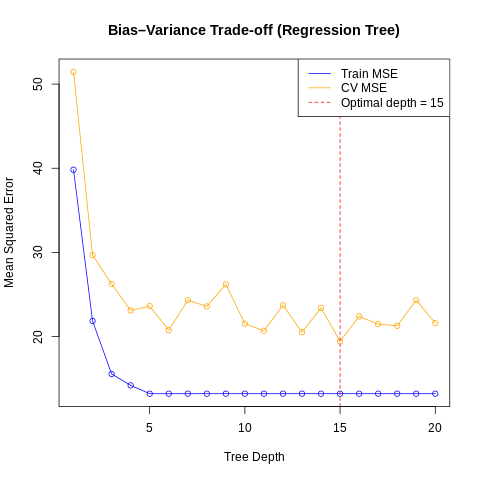

In [ ]:
%%R
set.seed(2025)
trainIndex <- createDataPartition(df$medv, p=0.7, list=FALSE)
train <- df[trainIndex, ]
test <- df[-trainIndex, ]

train_MSE <- c()
cv_MSE <- c()

depths <- 1:20
for (d in depths) {
  model <- rpart(medv ~ ., data=train, control=rpart.control(maxdepth=d))
  pred_train <- predict(model, train)
  train_MSE <- c(train_MSE, mse(train$medv, pred_train))

  # 5-fold CV
  ctrl <- trainControl(method="cv", number=5)
  cv_model <- train(medv ~ ., data=df, method="rpart",
                    trControl=ctrl,
                    tuneGrid=data.frame(cp=0.01),
                    control=rpart.control(maxdepth=d))
  cv_MSE <- c(cv_MSE, cv_model$results$RMSE^2)
}

best_depth <- depths[which.min(cv_MSE)]

plot(depths, train_MSE, type='o', col='blue', ylim=range(c(train_MSE, cv_MSE)),
     ylab="Mean Squared Error", xlab="Tree Depth", main="Bias–Variance Trade-off (Regression Tree)")
lines(depths, cv_MSE, type='o', col='orange')
abline(v=best_depth, col='red', lty=2)
legend("topright", legend=c("Train MSE","CV MSE", paste("Optimal depth =", best_depth)),
       col=c("blue","orange","red"), lty=c(1,1,2))


### 4) Variable Importance

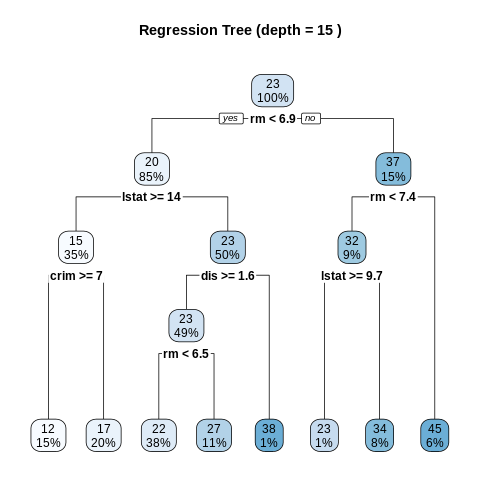

In [ ]:
%%R
rt_model <- rpart(medv ~ ., data=df, control=rpart.control(maxdepth=best_depth))

# Variable Importance
importance_df <- varImp(rt_model)

# Convert to data frame for plotting
importance_df <- data.frame(
  Feature = rownames(importance_df),
  Importance = importance_df$Overall
)

# Sort by importance (descending)
importance_df <- importance_df[order(importance_df$Importance, decreasing = TRUE), ]

# Standardization
importance_df$Importance <- importance_df$Importance / sum(importance_df$Importance)

# ---- Bar plot (top 10 features) ----
ggplot(importance_df[1:10, ], aes(x = reorder(Feature, Importance), y = Importance)) +
  geom_bar(stat = "identity", fill = "#2E86AB") +
  coord_flip() +
  theme_minimal(base_size = 12) +
  labs(title = paste("Top 10 Variable Importances (Regression Tree, depth =", best_depth, ")"),
       x = "Feature",
       y = "Importance")

rpart.plot(rt_model, main=paste("Regression Tree (depth =", best_depth, ")"))


## 1.2 Bagging & Random Forest

Regression Tree Test MSE: 18.3557 
Bagging Test MSE: 20.96488 
Random Forest Test MSE: 16.38978 


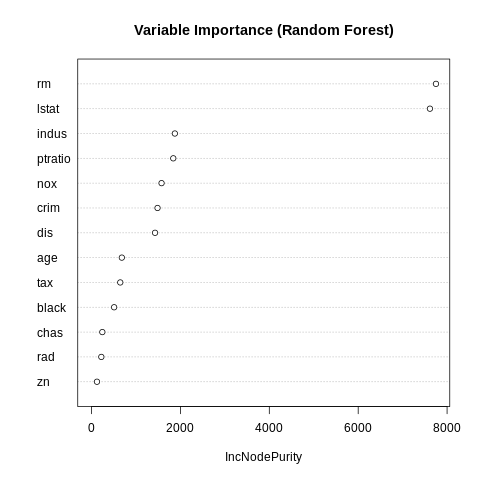

In [ ]:
%%R
set.seed(2025)
# Bagging
bag_model <- bagging(medv ~ ., data=train, nbagg=50)
rf_model <- randomForest(medv ~ ., data=train, ntree=50)

# Evaluate MSE
rt_pred <- predict(rt_model, test)
bag_pred <- predict(bag_model, test)
rf_pred <- predict(rf_model, test)

cat("Regression Tree Test MSE:", mse(test$medv, rt_pred), "\n")
cat("Bagging Test MSE:", mse(test$medv, bag_pred), "\n")
cat("Random Forest Test MSE:", mse(test$medv, rf_pred), "\n")

# Variable importance
importance(rf_model)
varImpPlot(rf_model, main="Variable Importance (Random Forest)")


## 2.1 Breast Cancer Dataset (Classification Tree)
### 1) Dataset Overview

In [ ]:
%%R
library(mlbench)
data("BreastCancer")
bc <- na.omit(BreastCancer)
bc$Class <- factor(bc$Class, levels=c("malignant","benign"))

# Check structure
cat("Data dimensions:", dim(bc), "\n")
print(head(bc))

bc <- bc[, !(names(bc) %in% c("Id"))]

Data dimensions: 683 11 
       Id Cl.thickness Cell.size Cell.shape Marg.adhesion Epith.c.size
1 1000025            5         1          1             1            2
2 1002945            5         4          4             5            7
3 1015425            3         1          1             1            2
4 1016277            6         8          8             1            3
5 1017023            4         1          1             3            2
6 1017122            8        10         10             8            7
  Bare.nuclei Bl.cromatin Normal.nucleoli Mitoses     Class
1           1           3               1       1    benign
2          10           3               2       1    benign
3           2           3               1       1    benign
4           4           3               7       1    benign
5           1           3               1       1    benign
6          10           9               7       1 malignant


### 2) K-Fold CV (Accuracy)

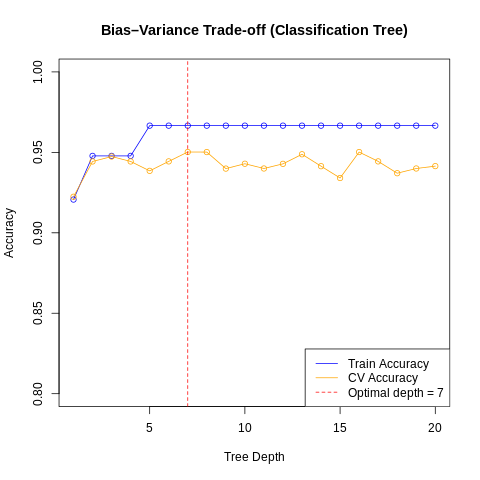

In [ ]:

%%R
set.seed(2025)
depths <- 1:20
trainIndex <- createDataPartition(bc$Class, p=0.7, list=FALSE)
train <- bc[trainIndex, ]
test <- bc[-trainIndex, ]

train_acc <- c()
cv_acc <- c()
ctrl <- trainControl(method="cv", number=5)

for (d in depths) {
  model <- rpart(Class ~ ., data=train, control=rpart.control(maxdepth=d))
  train_acc <- c(train_acc, mean(predict(model, train, type="class") == train$Class))
  cv_model <- train(Class ~ ., data=bc, method="rpart",
                    trControl=ctrl,
                    tuneGrid=data.frame(cp=0.01),
                    control=rpart.control(maxdepth=d))
  cv_acc <- c(cv_acc, max(cv_model$results$Accuracy))
}

best_depth <- depths[which.max(cv_acc)]
plot(depths, train_acc, type='o', col='blue', ylim=c(0.8,1),
     ylab="Accuracy", xlab="Tree Depth", main="Bias–Variance Trade-off (Classification Tree)")
lines(depths, cv_acc, type='o', col='orange')
abline(v=best_depth, col='red', lty=2)
legend("bottomright", legend=c("Train Accuracy","CV Accuracy", paste("Optimal depth =", best_depth)),
       col=c("blue","orange","red"), lty=c(1,1,2))


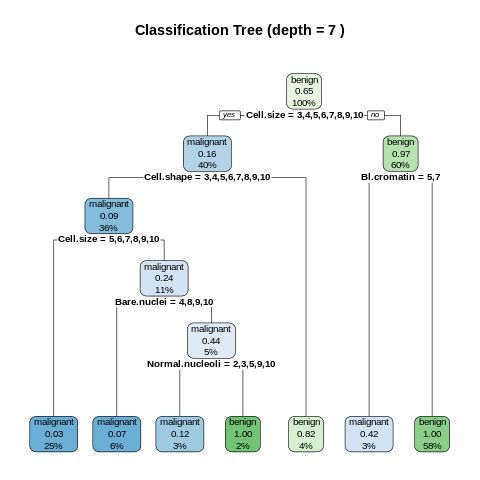

In [ ]:
%%R
# Visualizing Classification Tree
tree_clf <- rpart(Class ~ ., data=train, control=rpart.control(maxdepth=best_depth))
rpart.plot(tree_clf, main=paste("Classification Tree (depth =", best_depth, ")"))

### 3) Bagging & Random Forest

In [ ]:
%%R
# Bagging Tree
bag_clf  <- bagging(Class ~ ., data = train, nbagg = 50, coob = TRUE)

# Random Forest
rf_clf   <- randomForest(Class ~ ., data = train, ntree = 50, importance = TRUE)

# --- Predictions ---
tree_pred <- predict(tree_clf, test, type = "class")
bag_pred  <- predict(bag_clf,  test, type = "class")
rf_pred   <- predict(rf_clf,   test, type = "class")

# --- Accuracy Comparison ---
acc_tree <- mean(tree_pred == test$Class)
acc_bag  <- mean(bag_pred == test$Class)
acc_rf   <- mean(rf_pred == test$Class)

cat("Model Accuracies:\n")
cat(sprintf("Decision Tree:  %.3f\n", acc_tree))
cat(sprintf("Bagging:        %.3f\n", acc_bag))
cat(sprintf("Random Forest:  %.3f\n", acc_rf))

Model Accuracies:
Decision Tree:  0.946
Bagging:        0.975
Random Forest:  0.990


### 3) Confusion Matrix

In [ ]:
%%R
# --- Confusion Matrices ---
cat("\nConfusion Matrices:\n")
cat("\nDecision Tree:\n"); print(confusionMatrix(tree_pred, test$Class))
cat("\nBagging:\n");        print(confusionMatrix(bag_pred, test$Class))
cat("\nRandom Forest:\n");  print(confusionMatrix(rf_pred, test$Class))


Confusion Matrices:

Decision Tree:
Confusion Matrix and Statistics

           Reference
Prediction  malignant benign
  malignant        64      4
  benign            7    129
                                          
               Accuracy : 0.9461          
                 95% CI : (0.9056, 0.9728)
    No Information Rate : 0.652           
    P-Value [Acc > NIR] : <2e-16          
                                          
                  Kappa : 0.88            
                                          
 Mcnemar's Test P-Value : 0.5465          
                                          
            Sensitivity : 0.9014          
            Specificity : 0.9699          
         Pos Pred Value : 0.9412          
         Neg Pred Value : 0.9485          
             Prevalence : 0.3480          
         Detection Rate : 0.3137          
   Detection Prevalence : 0.3333          
      Balanced Accuracy : 0.9357          
                                          
     

### 4) ROC Curve

Setting direction: controls > cases
Setting direction: controls > cases
Setting direction: controls > cases


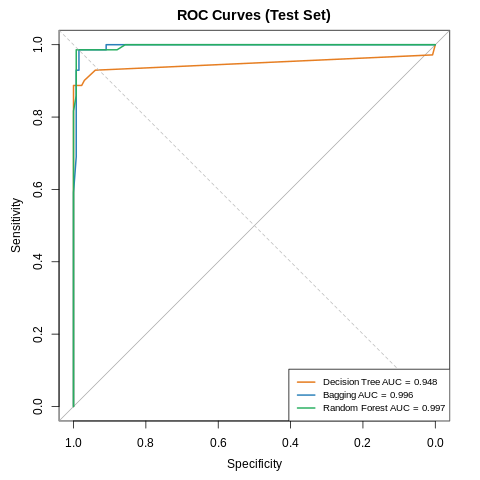

In [ ]:

%%R
# --- ROC Curves + AUC ---
tree_prob <- predict(tree_clf, test, type = "prob")[,2]
bag_prob  <- predict(bag_clf,  test, type = "prob")[,2]
rf_prob   <- predict(rf_clf,   test, type = "prob")[,2]

roc_tree <- pROC::roc(response = test$Class, predictor = tree_prob, levels = rev(levels(test$Class)))
roc_bag  <- pROC::roc(response = test$Class, predictor = bag_prob,  levels = rev(levels(test$Class)))
roc_rf   <- pROC::roc(response = test$Class, predictor = rf_prob,   levels = rev(levels(test$Class)))

plot(roc_tree, col = "#E67E22", lwd = 2, main = "ROC Curves (Test Set)")
plot(roc_bag,  col = "#2980B9", lwd = 2, add = TRUE)
plot(roc_rf,   col = "#27AE60", lwd = 2, add = TRUE)
abline(a = 0, b = 1, lty = 2, col = "gray")
legend("bottomright",
       legend = c(
         paste("Decision Tree AUC =", round(pROC::auc(roc_tree), 3)),
         paste("Bagging AUC =", round(pROC::auc(roc_bag), 3)),
         paste("Random Forest AUC =", round(pROC::auc(roc_rf), 3))
       ),
       col = c("#E67E22", "#2980B9", "#27AE60"), lwd = 2, cex = 0.8)

### 5) Variable Importance


(`geom_bar()`). 



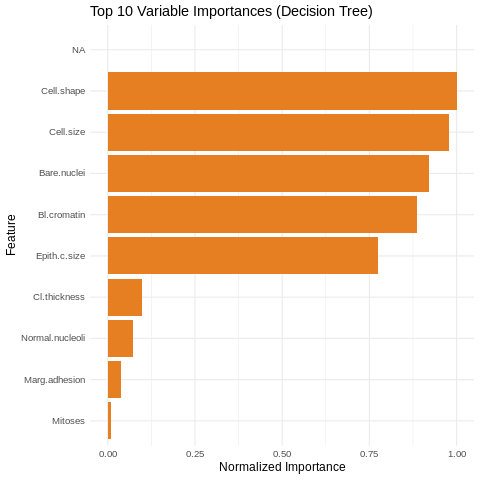

In [ ]:
%%R
# 1. Decision Tree importance
imp_tree_df <- varImp(tree_clf)
imp_tree_df <- data.frame(
  Feature = rownames(imp_tree_df),
  Importance = imp_tree_df$Overall
)

# Remove invalid or negative values
imp_tree_df <- imp_tree_df[is.finite(imp_tree_df$Importance) & imp_tree_df$Importance >= 0, ]

# Normalize
imp_tree_df$Importance <- imp_tree_df$Importance / max(imp_tree_df$Importance, na.rm = TRUE)

# Top 10
imp_tree_top <- imp_tree_df[order(imp_tree_df$Importance, decreasing = TRUE), ][1:10, ]

# Plot: Decision Tree
ggplot(imp_tree_top, aes(x = reorder(Feature, Importance), y = Importance)) +
  geom_bar(stat = "identity", fill = "#E67E22") +
  coord_flip() +
  theme_minimal(base_size = 12) +
  labs(title = "Top 10 Variable Importances (Decision Tree)",
       x = "Feature", y = "Normalized Importance")



(`geom_bar()`). 



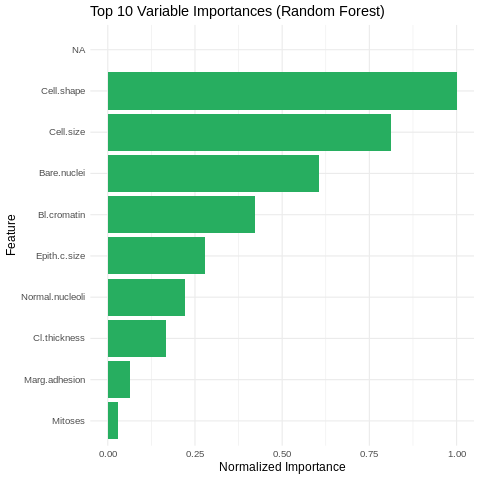

In [ ]:
%%R
# ---------------------------------------------------
# 2. Random Forest importance (use MeanDecreaseGini, always >= 0)
imp_rf <- importance(rf_clf)[, "MeanDecreaseGini"]
imp_rf_df <- data.frame(
  Feature = names(imp_rf),
  Importance = imp_rf
)

# Remove invalid or negative values
imp_rf_df <- imp_rf_df[is.finite(imp_rf_df$Importance) & imp_rf_df$Importance >= 0, ]

# Normalize
imp_rf_df$Importance <- imp_rf_df$Importance / max(imp_rf_df$Importance, na.rm = TRUE)

# Top 10
imp_rf_top <- imp_rf_df[order(imp_rf_df$Importance, decreasing = TRUE), ][1:10, ]


# Plot: Random Forest
ggplot(imp_rf_top, aes(x = reorder(Feature, Importance), y = Importance)) +
  geom_bar(stat = "identity", fill = "#27AE60") +
  coord_flip() +
  theme_minimal(base_size = 12) +
  labs(title = "Top 10 Variable Importances (Random Forest)",
       x = "Feature", y = "Normalized Importance")
